<a href="https://colab.research.google.com/github/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/blob/main/dsc_main_group_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Challenge — Seasonal Flu Vaccine Prediction


## Data Exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap

RANDOM_STATE = 42
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

LOAD DATA

In [ ]:
train = pd.read_csv("dataset_A_training.csv")
test  = pd.read_csv("dataset_A_testing.csv")
print(f"Train: {train.shape}")
print(f"Test : {test.shape}")
train.head()


Train: (4756, 31)
Test : (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,18 - 34 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,18 - 34 Years,Some College,White,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,1.0,65+ Years,College Graduate,White,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,3.0,1.0,55 - 64 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,3.0,1.0,1.0,55 - 64 Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


Exploratory Data Analysis (EDA)

Target balance check

Missing-value heatmap

Top-correlated features with target

Class-conditional distributions

The critical train/test column comparison

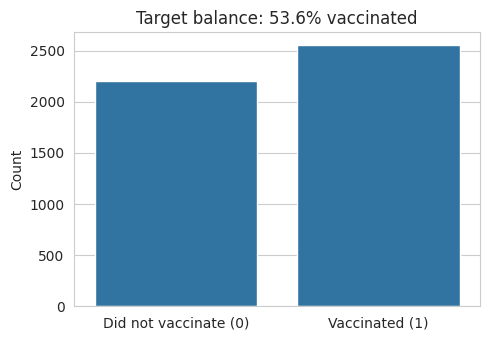

In [15]:
#EDA - 1 Target Variable
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = train['seasonal_vaccine'].value_counts().sort_index()
sns.barplot(x=['Did not vaccinate (0)', 'Vaccinated (1)'], y=counts.values, ax=ax)
ax.set_title(f"Target balance: {counts[1]/(counts[0]+counts[1]):.1%} vaccinated")
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

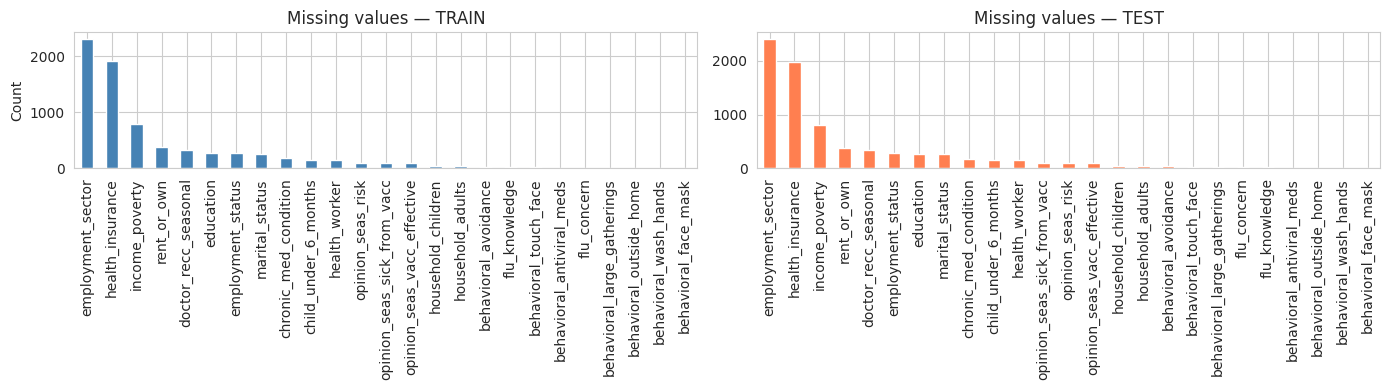

In [16]:
#EDA - 2 Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_train = train.isnull().sum().sort_values(ascending=False)
miss_test  = test.isnull().sum().sort_values(ascending=False)
miss_train[miss_train > 0].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Missing values — TRAIN')
axes[0].set_ylabel('Count')
miss_test[miss_test > 0].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Missing values — TEST')
plt.tight_layout(); plt.show()

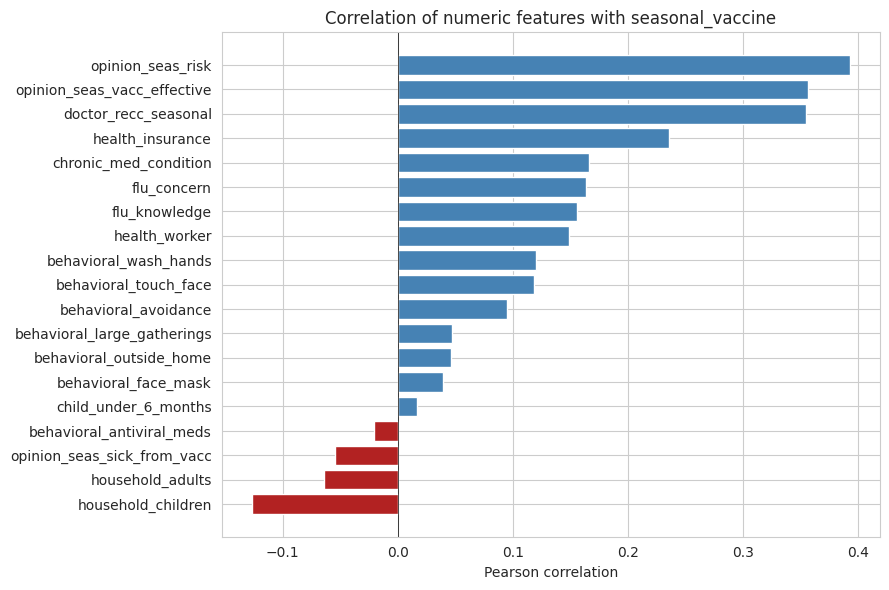

Top positive predictors:
chronic_med_condition          0.166
health_insurance               0.236
doctor_recc_seasonal           0.355
opinion_seas_vacc_effective    0.357
opinion_seas_risk              0.393


In [17]:
# EDA - 3 Correlation of numeric features with target
num_features = train.select_dtypes(include=np.number).columns.drop(['respondent_id','seasonal_vaccine'])
corrs = train[num_features].corrwith(train['seasonal_vaccine']).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['firebrick' if c < 0 else 'steelblue' for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.set_title('Correlation of numeric features with seasonal_vaccine')
ax.set_xlabel('Pearson correlation')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

print('Top positive predictors:')
print(corrs.tail(5).round(3).to_string())

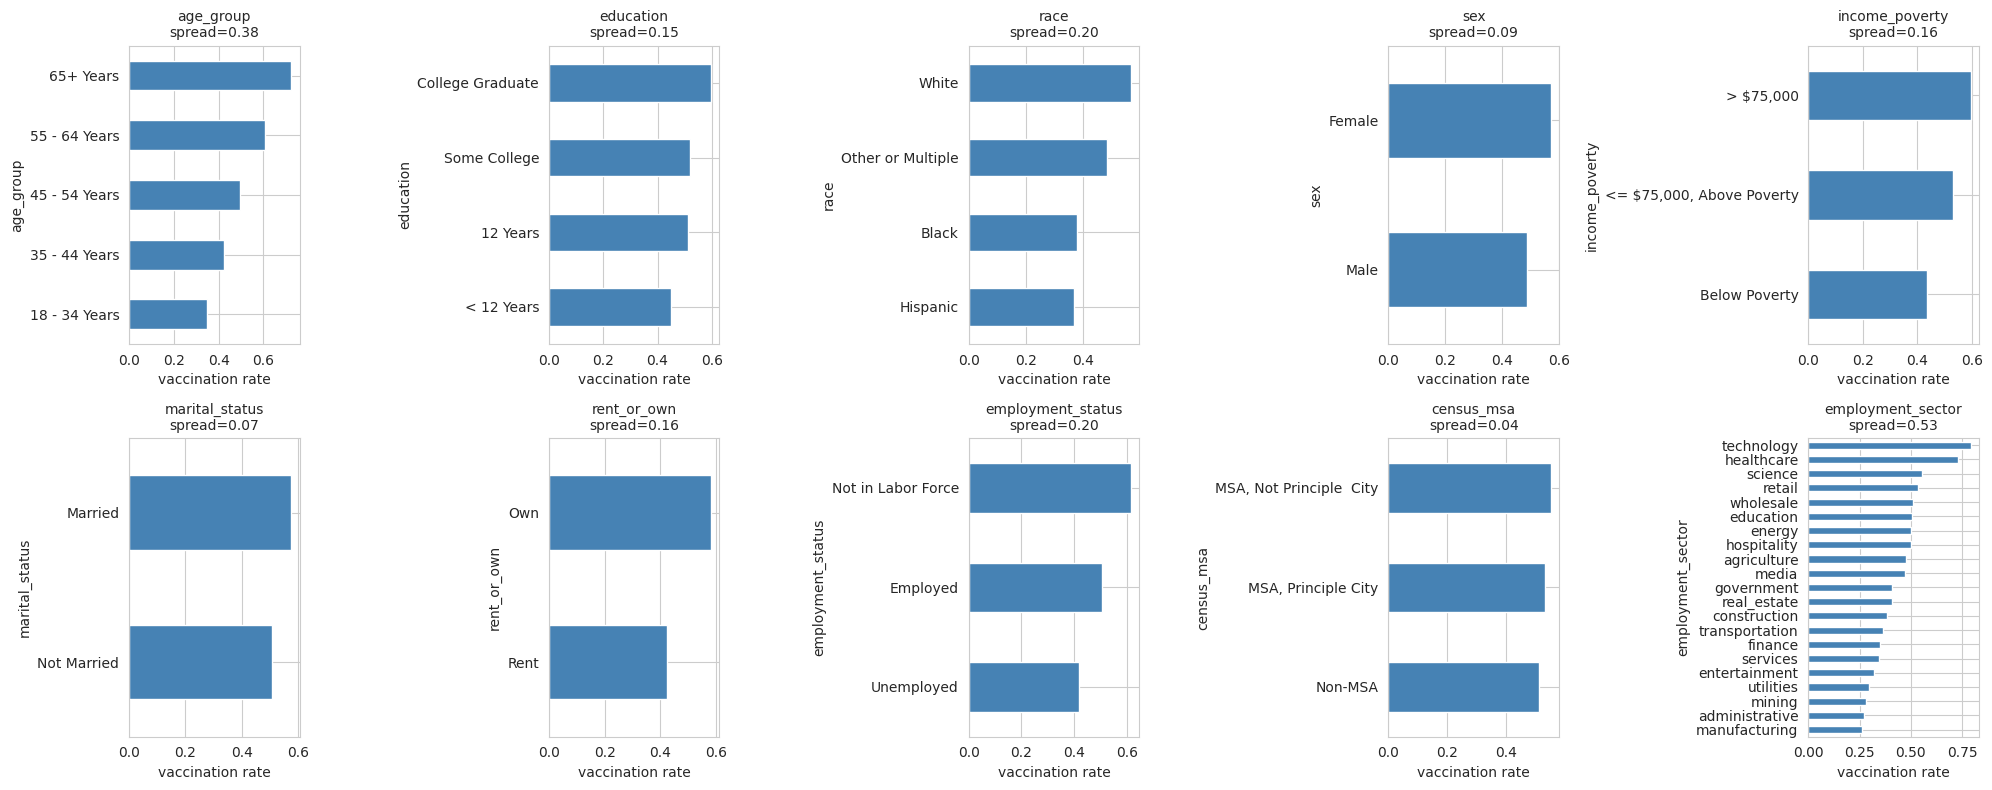

In [18]:
# EDA - 4 Categorical target rates
cat_features = train.select_dtypes(exclude=np.number).columns.tolist()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, cat_features):
    rates = train.groupby(col)['seasonal_vaccine'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{col}\nspread={rates.max()-rates.min():.2f}', fontsize=10)
    ax.set_xlabel('vaccination rate')
plt.tight_layout(); plt.show()